
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/diogoflim/Estatistica/blob/main/04_dist_continuas.ipynb)



# Estatística

## Engenharia de Produção

Prof. Diogo Ferreira de Lima Silva



Este notebook acompanha os tópicos da aula 4:

- variáveis aleatórias contínuas;
- função densidade de probabilidade (pdf);
- função distribuição acumulada (cdf);
- distribuição uniforme contínua;
- distribuição normal e normal padrão;
- aproximação normal para a binomial e para a Poisson;
- distribuição exponencial.


## 1. Importações

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm, binom, poisson, expon



## 2. pdf, cdf e área sob a curva

No caso contínuo, a função densidade de probabilidade $f_X(x)$ **não** fornece a probabilidade no ponto.
Em vez disso, a probabilidade aparece como **área sob a curva**:

$$P(a \leq X \leq b)=\int_a^b f_X(x)\,dx$$

Além disso, para variáveis contínuas,

$$P(X=x)=0$$

Vamos começar com um exemplo simples: $X \sim U(0,1)$.


In [2]:
# Exemplo inicial: X ~ U(0,1)
rv = uniform(loc=0, scale=1)

x = np.linspace(-0.2, 1.2, 500)
pdf = rv.pdf(x)
cdf = rv.cdf(x)

print(f"f_X(0.50) = {rv.pdf(0.5):.2f}")
print(f"P(X = 0.50) = 0")
print(f"P(0.20 <= X <= 0.70) = {rv.cdf(0.7) - rv.cdf(0.2):.2f}")


f_X(0.50) = 1.00
P(X = 0.50) = 0
P(0.20 <= X <= 0.70) = 0.50


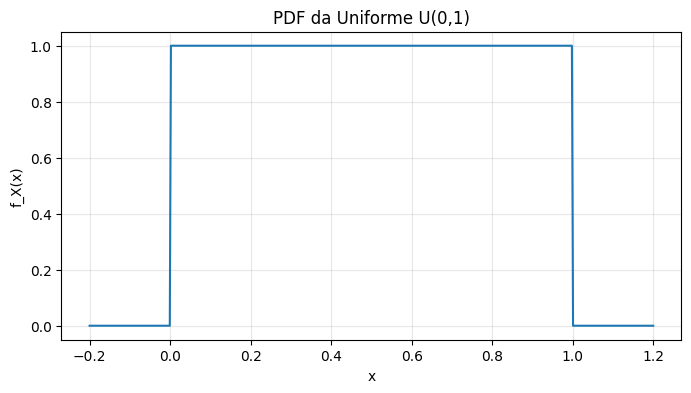

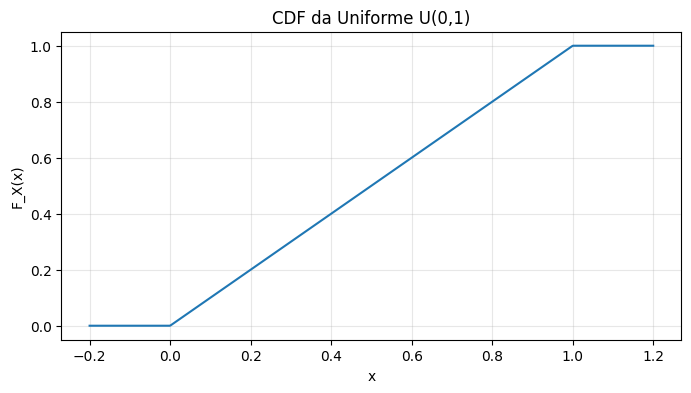

In [3]:
# Visualização da pdf e da cdf
plt.figure(figsize=(8, 4))
plt.plot(x, pdf)
plt.title('PDF da Uniforme U(0,1)')
plt.xlabel('x')
plt.ylabel('f_X(x)')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(x, cdf)
plt.title('CDF da Uniforme U(0,1)')
plt.xlabel('x')
plt.ylabel('F_X(x)')
plt.grid(alpha=0.3)
plt.show()



### Exercício 1

Considere $X \sim U(0,1)$.

1. Calcule $P(0.10 \leq X \leq 0.35)$ usando a cdf.
2. Calcule $P(X>0.80)$.
3. Gere um gráfico da pdf e destaque visualmente o intervalo $[0.10,0.35]$.

> Tente fazer sozinho antes de abrir a solução.


P(0.10 <= X <= 0.35) = 0.2500
P(X > 0.80) = 0.2000


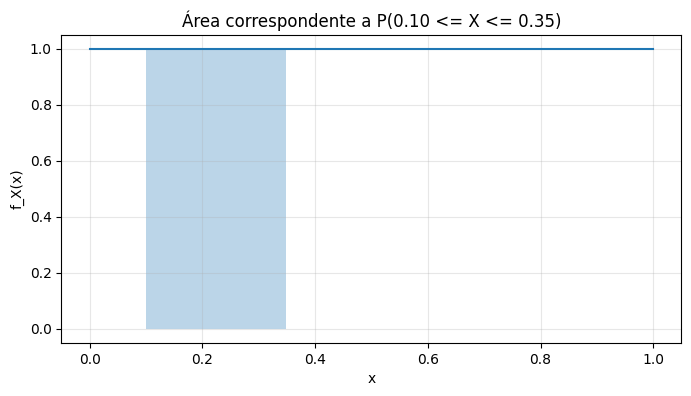

In [4]:
# Solução do Exercício 1
rv = uniform(loc=0, scale=1)

prob_1 = rv.cdf(0.35) - rv.cdf(0.10)
prob_2 = 1 - rv.cdf(0.80)

print(f"P(0.10 <= X <= 0.35) = {prob_1:.4f}")
print(f"P(X > 0.80) = {prob_2:.4f}")

x = np.linspace(0, 1, 400)
y = rv.pdf(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y)
mascara = (x >= 0.10) & (x <= 0.35)
plt.fill_between(x[mascara], y[mascara], alpha=0.3)
plt.title('Área correspondente a P(0.10 <= X <= 0.35)')
plt.xlabel('x')
plt.ylabel('f_X(x)')
plt.grid(alpha=0.3)
plt.show()


# 3. Distribuição Uniforme Contínua


Se $X \sim U(a,b)$, então:

$$f_X(x)=\frac{1}{b-a},\quad a \leq x \leq b$$

$$F_X(x)=\frac{x-a}{b-a},\quad a \leq x \leq b$$

$$E(X)=\frac{a+b}{2}, \qquad Var(X)= \frac{(b-a)^2}{12}$$

Vamos reproduzir computacionalmente o exercício do tempo para a anestesia fazer efeito.


In [5]:
# Exemplo: tempo para anestesia fazer efeito ~ U(15, 30)
a, b = 15, 30
rv_unif = uniform(loc=a, scale=b-a)

media = rv_unif.mean()
desvio = rv_unif.std()
prob_20_25 = rv_unif.cdf(25) - rv_unif.cdf(20)

print(f"Média = {media:.2f} minutos")
print(f"Desvio-padrão = {desvio:.2f} minutos")
print(f"P(20 <= X <= 25) = {prob_20_25:.4f}")


Média = 22.50 minutos
Desvio-padrão = 4.33 minutos
P(20 <= X <= 25) = 0.3333


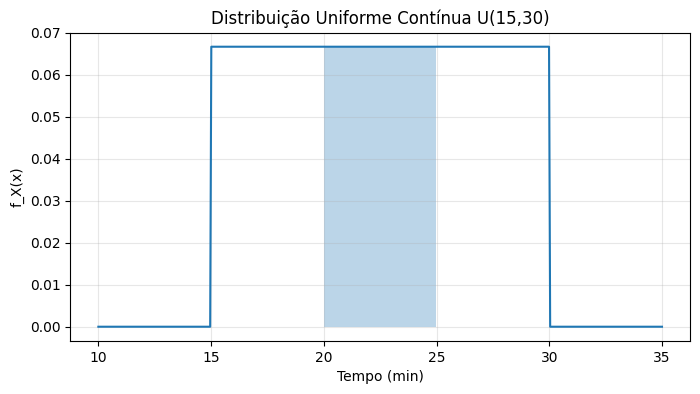

In [6]:
# Visualização da distribuição uniforme contínua
x = np.linspace(10, 35, 500)
y = rv_unif.pdf(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y)
mascara = (x >= 20) & (x <= 25)
plt.fill_between(x[mascara], y[mascara], alpha=0.3)
plt.title('Distribuição Uniforme Contínua U(15,30)')
plt.xlabel('Tempo (min)')
plt.ylabel('f_X(x)')
plt.grid(alpha=0.3)
plt.show()



### Exercício 2

Suponha que o tempo de atendimento em um guichê seja modelado por uma uniforme contínua no intervalo de 4 a 10 minutos.

1. Calcule a média e o desvio-padrão.
2. Calcule $P(X\leq 6)$.
3. Calcule $P(5\leq X\leq 8)$.
4. Monte uma tabela com os valores de pdf e cdf nos pontos 4, 5, 6, 7, 8, 9 e 10.


In [7]:

# Solução do Exercício 2
a, b = 4, 10
rv_unif2 = uniform(loc=a, scale=b-a)

print(f"Média = {rv_unif2.mean():.2f}")
print(f"Desvio-padrão = {rv_unif2.std():.2f}")
print(f"P(X <= 6) = {rv_unif2.cdf(6):.4f}")
print(f"P(5 <= X <= 8) = {rv_unif2.cdf(8) - rv_unif2.cdf(5):.4f}")

pontos = np.arange(4, 11)
tabela = pd.DataFrame({
    'x': pontos,
    'pdf': rv_unif2.pdf(pontos),
    'cdf': rv_unif2.cdf(pontos)
})

tabela


Média = 7.00
Desvio-padrão = 1.73
P(X <= 6) = 0.3333
P(5 <= X <= 8) = 0.5000


,x,pdf,cdf
0,4,0.166667,0.000000
1,5,0.166667,0.166667
2,6,0.166667,0.333333
3,7,0.166667,0.500000
4,8,0.166667,0.666667
5,9,0.166667,0.833333
6,10,0.166667,1.000000


# 4. Distribuição Normal


A distribuição normal é uma das mais importantes da estatística. Se $X \sim N(\mu,\sigma)$, então:

$$f_X(x)=
\frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

A curva é simétrica em torno de $\mu$ e tem formato de sino.


In [9]:

# Exemplo: duração do tubo de imagem ~ N(6, 1.5)
mu = 6
sigma = 1.5
rv_norm = norm(loc=mu, scale=sigma)

prob_mais_8 = 1 - rv_norm.cdf(8)
prob_menos_2 = rv_norm.cdf(2)
prob_troca = rv_norm.cdf(3)

print(f"P(X > 8) = {prob_mais_8:.4f}")
print(f"P(X < 2) = {prob_menos_2:.4f}")
print(f"P(X <= 3) = {prob_troca:.4f}")


P(X > 8) = 0.0912
P(X < 2) = 0.0038
P(X <= 3) = 0.0228


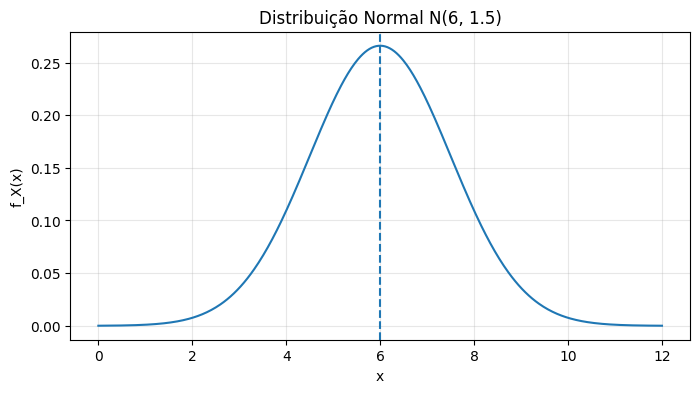

In [10]:
# Visualização da normal
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
y = rv_norm.pdf(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y)
plt.axvline(mu, linestyle='--')
plt.title('Distribuição Normal N(6, 1.5)')
plt.xlabel('x')
plt.ylabel('f_X(x)')
plt.grid(alpha=0.3)
plt.show()



## 5. Normal padrão e padronização

Se $X\sim N(\mu,\sigma)$, então a variável

$$Z=
\frac{X-\mu}{\sigma}$$

segue uma distribuição normal padrão, isto é, $Z\sim N(0,1)$.

Isso é útil porque podemos transformar qualquer problema envolvendo uma normal geral em um problema envolvendo a normal padrão.


In [11]:

# Padronizando alguns valores
valores_x = np.array([3, 6, 8])
z = (valores_x - mu) / sigma

for x_val, z_val in zip(valores_x, z):
    print(f"x = {x_val:.1f}  ->  z = {z_val:.4f}")


x = 3.0  ->  z = -2.0000
x = 6.0  ->  z = 0.0000
x = 8.0  ->  z = 1.3333


In [12]:

# Probabilidades usando a normal padrão
rv_z = norm(loc=0, scale=1)

prob_z = rv_z.cdf(1.96) - rv_z.cdf(-1.96)
print(f"P(-1.96 <= Z <= 1.96) = {prob_z:.4f}")


P(-1.96 <= Z <= 1.96) = 0.9500



### Exercício 3

Considere $X\sim N(70,8)$.

1. Calcule $P(X\leq 80)$.
2. Calcule $P(X\geq 60)$.
3. Padronize os valores 60, 70 e 80.
4. Faça o gráfico da densidade e marque a média e os pontos correspondentes a 60 e 80.


P(X <= 80) = 0.8944
P(X >= 60) = 0.8944
z(60) = -1.2500
z(70) = 0.0000
z(80) = 1.2500


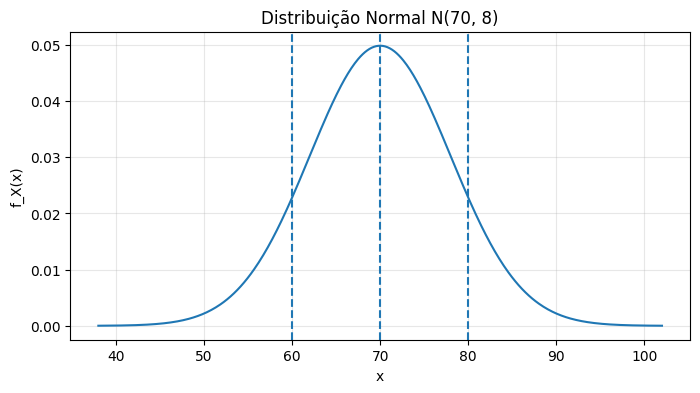

In [13]:

# Solução do Exercício 3
mu = 70
sigma = 8
rv = norm(loc=mu, scale=sigma)

print(f"P(X <= 80) = {rv.cdf(80):.4f}")
print(f"P(X >= 60) = {1 - rv.cdf(60):.4f}")

for valor in [60, 70, 80]:
    z = (valor - mu)/sigma
    print(f"z({valor}) = {z:.4f}")

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
plt.figure(figsize=(8, 4))
plt.plot(x, rv.pdf(x))
plt.axvline(60, linestyle='--')
plt.axvline(70, linestyle='--')
plt.axvline(80, linestyle='--')
plt.title('Distribuição Normal N(70, 8)')
plt.xlabel('x')
plt.ylabel('f_X(x)')
plt.grid(alpha=0.3)
plt.show()


## 6. Aproximação normal para a binomial


Quando $n$ é grande e $p$ não é muito próximo de 0 ou 1, a distribuição binomial pode ser aproximada por uma normal com:

$$\mu=np, \qquad \sigma=\sqrt{np(1-p)}$$

Em geral, também usamos **correção de continuidade**.


In [14]:
# Exemplo: mais do que 17 caras em 32 lançamentos de uma moeda honesta
n = 32
p = 0.5
rv_bin = binom(n, p)

# Exato
prob_exata = 1 - rv_bin.cdf(17)

# Aproximação normal com correção de continuidade: P(X > 17) ~ P(Y > 17.5)
mu = n * p
sigma = np.sqrt(n * p * (1 - p))
rv_aprox = norm(loc=mu, scale=sigma)
prob_aprox = 1 - rv_aprox.cdf(17.5)

print(f"Probabilidade exata   = {prob_exata:.4f}")
print(f"Aproximação normal    = {prob_aprox:.4f}")


Probabilidade exata   = 0.2983
Aproximação normal    = 0.2979


## 7. Aproximação normal para a Poisson


Quando $\lambda$ é grande, a distribuição de Poisson pode ser aproximada por uma normal com:

$$\mu=\lambda, \qquad \sigma=\sqrt{\lambda}$$

Também devemos utilizar correção de continuidade.


In [15]:

# Exemplo: média de 84 chamadas em 2 horas. Probabilidade de mais do que 50 chamadas.
lambda_ = 84
rv_pois = poisson(lambda_)

# Exato
prob_exata = 1 - rv_pois.cdf(50)

# Aproximação normal com correção de continuidade
rv_norm_aprox = norm(loc=lambda_, scale=np.sqrt(lambda_))
prob_aprox = 1 - rv_norm_aprox.cdf(50.5)

print(f"Probabilidade exata = {prob_exata:.6f}")
print(f"Aproximação normal  = {prob_aprox:.6f}")


Probabilidade exata = 0.999958
Aproximação normal  = 0.999871


# 8. Distribuição Exponencial


A distribuição exponencial modela tempos de espera até o próximo evento. Se $X\sim Exp(\lambda)$, então:

$$f_X(x)=\lambda e^{-\lambda x}, \quad x\geq 0$$

$$F_X(x)=1-e^{-\lambda x}, \quad x\geq 0$$

Ela está diretamente relacionada à distribuição de Poisson:

- **Poisson** conta quantos eventos ocorrem;
- **Exponencial** mede o tempo entre eventos.


In [16]:
# Exemplo: taxa média de 2.2 chamadas por minuto
lambda_ = 2.2
rv_exp = expon(scale=1/lambda_)

# 30 segundos = 0.5 minuto
prob_mais_30s = 1 - rv_exp.cdf(0.5)

print(f"E(X) = {rv_exp.mean():.4f} minuto(s)")
print(f"DP(X) = {rv_exp.std():.4f} minuto(s)")
print(f"P(X > 0.5) = {prob_mais_30s:.4f}")


E(X) = 0.4545 minuto(s)
DP(X) = 0.4545 minuto(s)
P(X > 0.5) = 0.3329


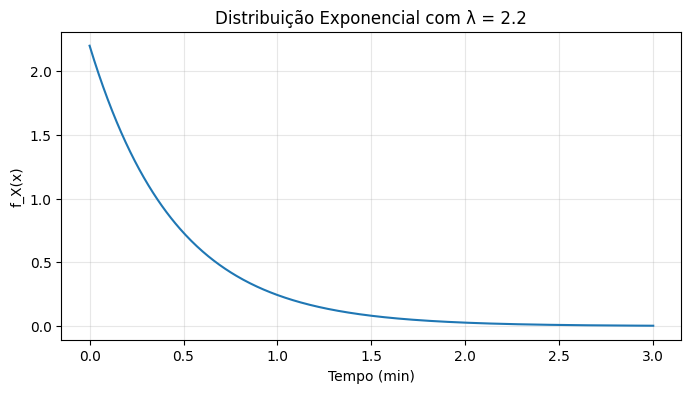

In [17]:
# Visualização da exponencial
x = np.linspace(0, 3, 500)
plt.figure(figsize=(8, 4))
plt.plot(x, rv_exp.pdf(x))
plt.title('Distribuição Exponencial com λ = 2.2')
plt.xlabel('Tempo (min)')
plt.ylabel('f_X(x)')
plt.grid(alpha=0.3)
plt.show()



### Exercício 4

Considere uma variável aleatória exponencial com taxa $\lambda=0.25$ por hora.

1. Calcule o tempo médio de espera.
2. Calcule o desvio-padrão.
3. Calcule $P(X\leq 2)$.
4. Calcule $P(X>5)$.
5. Faça um gráfico da densidade no intervalo de 0 a 12 horas.


Tempo médio = 4.0000 horas
Desvio-padrão = 4.0000 horas
P(X <= 2) = 0.3935
P(X > 5) = 0.2865


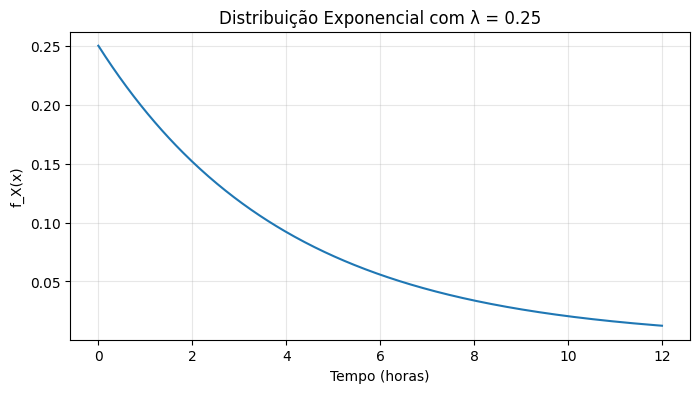

In [18]:

# Solução do Exercício 4
lambda_ = 0.25
rv = expon(scale=1/lambda_)

print(f"Tempo médio = {rv.mean():.4f} horas")
print(f"Desvio-padrão = {rv.std():.4f} horas")
print(f"P(X <= 2) = {rv.cdf(2):.4f}")
print(f"P(X > 5) = {1 - rv.cdf(5):.4f}")

x = np.linspace(0, 12, 400)
plt.figure(figsize=(8, 4))
plt.plot(x, rv.pdf(x))
plt.title('Distribuição Exponencial com λ = 0.25')
plt.xlabel('Tempo (horas)')
plt.ylabel('f_X(x)')
plt.grid(alpha=0.3)
plt.show()



## 9. Simulação

Uma forma de reforçar a intuição sobre distribuições contínuas é simular amostras e comparar o histograma com a densidade teórica.


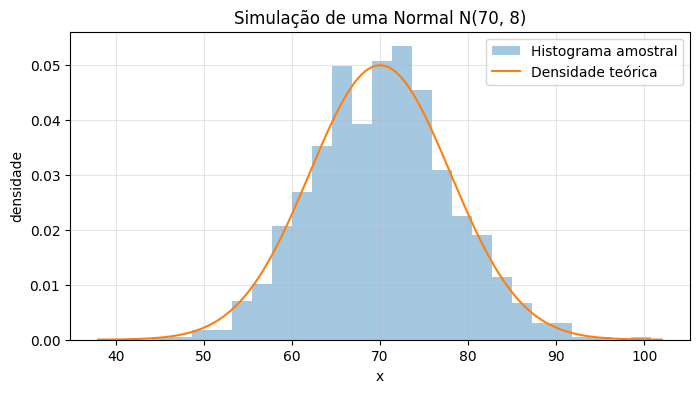

In [19]:

# Simulando amostras de uma normal e comparando com a densidade teórica
np.random.seed(42)
mu = 70
sigma = 8
amostra = np.random.normal(loc=mu, scale=sigma, size=1000)

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
rv = norm(loc=mu, scale=sigma)

plt.figure(figsize=(8, 4))
plt.hist(amostra, bins=25, density=True, alpha=0.4, label='Histograma amostral')
plt.plot(x, rv.pdf(x), label='Densidade teórica')
plt.title('Simulação de uma Normal N(70, 8)')
plt.xlabel('x')
plt.ylabel('densidade')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
